In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [13]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv' # URL del dataset
df = pd.read_csv(url, sep=';') # Carga el dataset
df.head() # Muestra las primeras filas del DataFrame

df.info() # Información sobre el DataFrame
df.describe() # Estadísticas descriptivas

print("Media de calidad:", df['quality'].mean()) # Media de la columna 'quality'
print("Mediana de calidad:", df['quality'].median()) # Mediana de la columna 'quality'
print("Moda de calidad:", df['quality'].mode()[0]) # Moda de la columna 'quality'

print("Rango de alcohol:", df['alcohol'].max() - df['alcohol'].min()) # Rango de la columna 'alcohol'
print("Desviacion estandar del PH:", df['pH'].std()) # Desviación estándar de la columna 'pH'
print("Varianza del acido citrico:", df['citric acid'].var()) # Varianza de la columna 'citric acid'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
Media de calidad: 5.6360225140712945
Mediana de calidad: 6.0
Moda de calidad: 5
Rango de alcohol: 6.5
Desviacion estandar del 

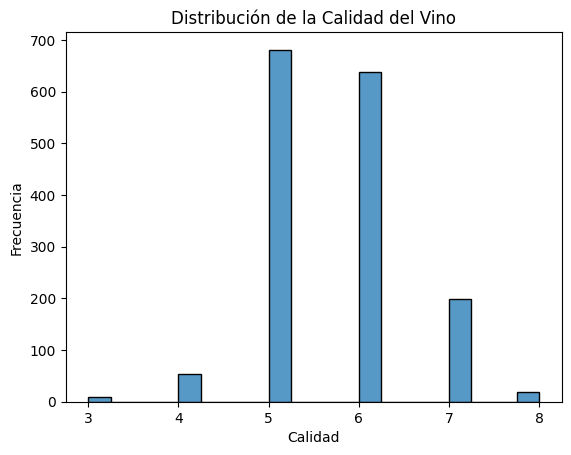

In [14]:
sns.histplot(df['quality'], bins=20, kde=False) # Histograma de la columna 'quality'
plt.title('Distribución de la Calidad del Vino')
plt.xlabel('Calidad')
plt.ylabel('Frecuencia')
plt.show()

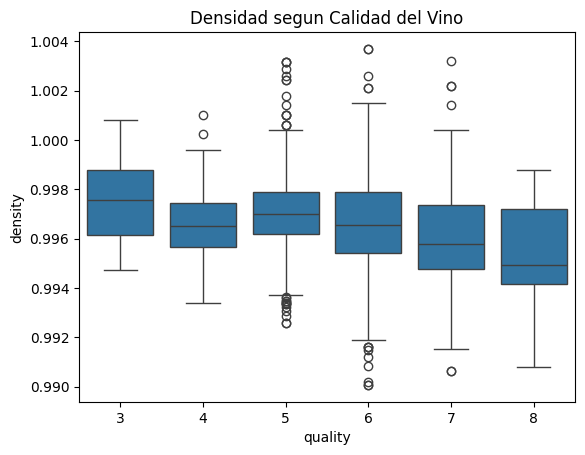

In [ ]:
sns.boxplot(x='quality', y='density', data=df) # Boxplot de 'alcohol' por 'desnsity'
plt.title('Densidad segun Calidad del Vino')
plt.show()

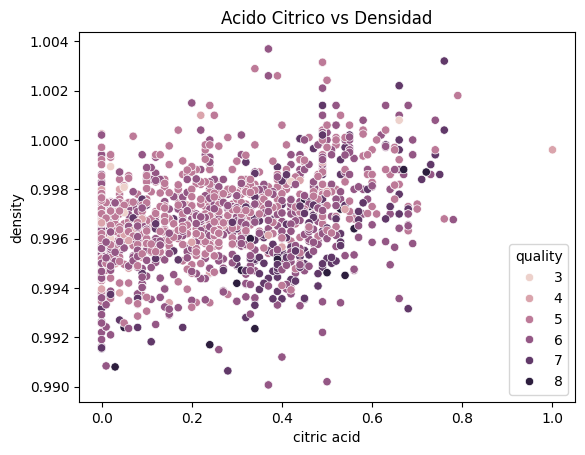

In [19]:
sns.scatterplot(x= 'citric acid', y='density', hue='quality', data=df) # Scatter plot de 'citric acid' vs 'density' coloreado por 'quality'
plt.title('Acido Citrico vs Densidad')
plt.show()

In [20]:
df.groupby('quality')['alcohol'].mean() # Media de 'alcohol' por cada nivel de 'quality'


quality
3     9.955000
4    10.265094
5     9.899706
6    10.629519
7    11.465913
8    12.094444
Name: alcohol, dtype: float64

In [ ]:
df.groupby("quality").agg({
    "alcohol": ["mean", "median", "std"], # Media, mediana y desviación estándar de 'alcohol' por cada nivel de 'quality'
    "pH": ["median"],  # Mediana de 'pH' por cada nivel de 'quality'
    "density": ["mean",]}) # Media de 'density' por cada nivel de 'quality'

alcohol                       pH   density
              mean  median       std median      mean
quality                                              
3         9.955000   9.925  0.818009   3.39  0.997464
4        10.265094  10.000  0.934776   3.37  0.996542
5         9.899706   9.700  0.736521   3.30  0.997104
6        10.629519  10.500  1.049639   3.32  0.996615
7        11.465913  11.500  0.961933   3.28  0.996104
8        12.094444  12.150  1.224011   3.23  0.995212

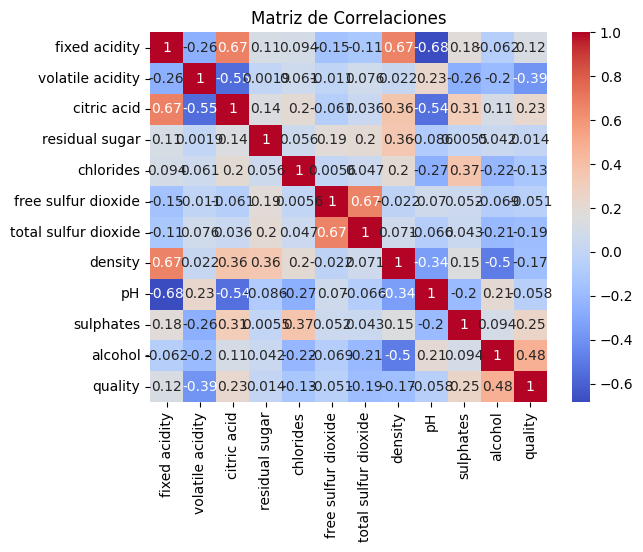

In [ ]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm') # Mapa de calor de la matriz de correlación
plt.title('Matriz de Correlaciones')
plt.show()

<Axes: xlabel='fixed acidity', ylabel='density'>

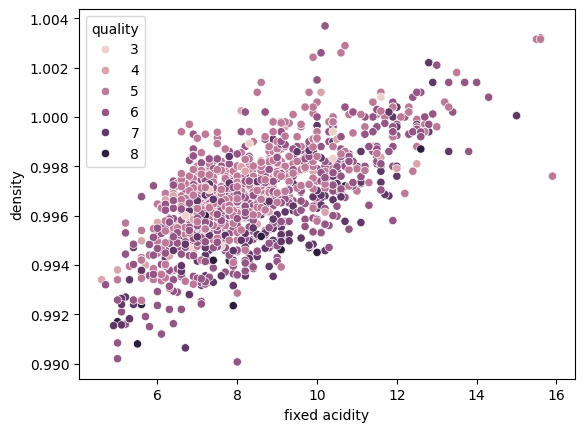

In [ ]:
sns.scatterplot(x='fixed acidity', y='density', hue='quality', data=df) # Scatter plot de 'fixed acidity' vs 'density' coloreado por 'quality'
